In [1]:
import torch
import json
import os

from data.ae_dataset import AEDataset
from torch import linalg as LA
import numpy as np
from matplotlib.pyplot import plot
from tqdm import tqdm
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display, Markdown, display_markdown # to display images

# Global variable

In [2]:
rec_seq = torch.load("model_outputs/rec_seq_0724_204251_v9.pt")   # [10377, 10, 512]

ori_seq = torch.load("model_outputs/ori_seq_0724_204251_v9.pt")   # [10377, 10, 512]

all_emb_path = os.path.join("./processed_data", "mean_pooled_emb.pt")
all_emb = torch.load(all_emb_path)   # [141245, 512]

all_md_path = os.path.join("./processed_data", "emb_idx_filtered.json")
with open(all_md_path, 'r') as fp:
    all_md = json.load(fp)   # .shape[0]=141245

# Display norm

In [3]:
# For rec_seq
all_rec_norm_list = []
for seq in rec_seq:
    # seq: [10, 512]
    norm_list = []
    for emb in seq:
        # emb: [512]
        norm_list.append(LA.norm(emb).item())
    all_rec_norm_list.append(norm_list)

In [21]:
# For ori_seq
all_ori_norm_list = []
for seq in ori_seq:
    # seq: [10, 512]
    norm_list = []
    for emb in seq:
        # emb: [512]
        norm_list.append(LA.norm(emb).item())
    all_ori_norm_list.append(norm_list)

In [5]:
assert len(all_rec_norm_list) == len(all_ori_norm_list)

In [ ]:
all_rec_norm_list[9]

In [ ]:
plot(range(10), all_rec_norm_list[9])

# Find the closest part

In [5]:
# find the pad for ori, compute the 'mask'
eps = 0.5
threshold = 0.5

## Find part in the entire part embedding space

In [6]:
def find_closest(emb, indices=list(range(len(all_emb)))):
    delta = all_emb - emb   # [141245, 512]
    dist = LA.norm(delta, dim=1)   #[141245]
    indices = torch.LongTensor(indices)
    min_val = torch.min(torch.index_select(dist, 0, indices)).item()
#     print(f'min: {dist[indices].min()}, max: {dist[indices].max()}')
#     idx = dist.argmin()   # If there are multiple minimal values then the indices of the first minimal value are returned.
    idx_tuple = (dist == min_val).nonzero(as_tuple=True)[0]   # first [0]: (tensor([91286]),) second[0]: remove multiple values
    for idx in idx_tuple:
        if idx in indices:
            return idx.item(), dist[idx].item()
    
    idx = idx_tuple[0]
    return idx.item(), dist[idx].item()

In [8]:
all_rec_closest_emb_list = []
for i, seq in tqdm(enumerate(rec_seq[:2, :, :])):
    closest_emb_list = []
    for j, rec_emb in enumerate(seq):
        if all_rec_norm_list[i][j] < eps:
            break
        closest_emb_idxm _ = find_closest(rec_emb)
        closest_emb_list.append(closest_emb_idx)
    all_rec_closest_emb_list.append(closest_emb_list)

2it [00:00,  4.50it/s]


In [50]:
all_ori_closest_emb_list = []
for i, seq in tqdm(enumerate(ori_seq[:5, :, :])):
    closest_emb_list = []
    for j, ori_emb in enumerate(seq):
        if all_ori_norm_list[i][j] < eps:
            break
        closest_emb_idx, _ = find_closest(ori_emb)
        closest_emb_list.append(closest_emb_idx)
    all_ori_closest_emb_list.append(closest_emb_list)

5it [00:01,  3.07it/s]


In [10]:
all_rec_closest_emb_list[:10]

[[91286, 99916, 74102],
 [24160, 47198, 86656],
 [90792, 11038, 48540, 102414],
 [93995, 25065],
 [18003, 104101],
 [13875, 25043],
 [58667, 69556],
 [83671, 139079],
 [79231, 17919],
 [86655, 48717, 18786]]

In [103]:
all_ori_closest_emb_list

[[129259, 129260],
 [129260, 129259],
 [96139, 96143, 96146, 96148, 96149],
 [96140, 96147, 96142, 96143, 96151, 96148, 96149, 96141],
 [96141, 96143, 96140],
 [96142, 96143, 96140],
 [96143, 96147, 96142, 96150, 96151, 96152, 96146, 96139, 96148, 96149],
 [96146, 96143, 96139],
 [96147, 96143, 96140],
 [96148, 96143, 96139, 96140]]

In [33]:
all_md[129259]

'0000_79682_b75071d6_cf962214-059a-11ec-9f7a-02631ee0d5cb_0000'

## Find part in the same assembly (top-k)

In [7]:
def find_topk_closest(emb, k=10):
    
    delta = all_emb - emb   # [141245, 512]
    dist = LA.norm(delta, dim=1)   # [141245]
    sorted_dist, indices = torch.sort(dist)
    topk_indices = indices[:k]   # The k closest (out of all) part embedding's indices
    
    return topk_indices

In [8]:
def compute_aid_to_part_indice_map():
    the_map = dict()
    assert len(all_md) == all_emb.shape[0]
    for idx, md in enumerate(all_md):
        aid = '_'.join(md.split('_')[1:3])
        if aid in the_map:
            the_map[aid].append(idx)
        else:
            the_map[aid] = []
            the_map[aid].append(idx)
    
    return the_map

In [9]:
aid_to_part_indice_map = compute_aid_to_part_indice_map()   # 8146 assemblies

In [11]:
len(aid_to_part_indice_map)

8146

In [10]:
def find_part(emb, ind):

    img_name = all_md[ind]
    aid = '_'.join(img_name.split('_')[1:3])
    constraint_indices = aid_to_part_indice_map[aid]
    part_idx = find_closest(emb, constraint_indices)
    
    return part_idx
    

In [ ]:
all_decoded_seq_list = []   # list of list of list

for i, seq in tqdm(enumerate(rec_seq[:5, :, :])):   # for each reconstructed part embedding sequence
    candi_part_indices = find_topk_closest(seq[0])   # find topk closest part embedding of the central part embedding
    decoded_seq_list = []   # list of list
    for candi_part_index in candi_part_indices:
        decoded_seq = []   # store the decoded seq constrained by candi_part_index
        decoded_seq.append(candi_part_index.item())
        for j, rec_emb in enumerate(seq):   # for each neighbouring part embedding
            if j==0:   # Skip decoding the first(central) part embedding
                continue
            
            if all_rec_norm_list[i][j] < eps:   # if norm < eps, stop decoding, should check on the first(central) part?
                break
            
            part_idx = find_part(rec_emb, candi_part_index)   # find the closest part index constrained by candi_part_index
            decoded_seq.append(part_idx)
            
        decoded_seq_list.append(decoded_seq)   # add the decoded_seq
            
    all_decoded_seq_list.append(decoded_seq_list)

In [180]:
all_decoded_seq_list[45]

[[19408, 19408, 19408, 19408, 19408],
 [34926, 34926, 34920, 34926, 34926],
 [34923, 34926, 34920, 34926, 34926],
 [34932, 34926, 34920, 34926, 34926],
 [34929, 34926, 34920, 34926, 34926],
 [104793, 104782, 104782, 104793, 104793],
 [45658, 45658, 45658, 45658, 45658],
 [77760, 77760, 77760, 77759, 77759],
 [40641, 40641, 40668, 40641, 40688],
 [40617, 40641, 40668, 40641, 40688]]

# Find part in the same assembly for all assemblies

In [11]:
def compute_decoded_seq(seq_idx, seq, indices):
    decoded_seq = []
    total_dist = 0.0
    total = 0
    for j, emb in enumerate(seq):
        if all_rec_norm_list[seq_idx][j] < eps:   # if norm < eps, stop decoding, should check on the first(central) part?
            break
        if len(indices)==0:
            break
        idx, local_dist = find_closest(emb, indices)
        decoded_seq.append(idx)
        total_dist += local_dist
#         print(indices)
#         print(idx)
        indices.remove(idx)
        total += 1
    
    return decoded_seq, total_dist / total if total != 0 else 100000

In [16]:
all_decoded_seq_list = []
for i, seq in tqdm(enumerate(rec_seq[:1, :, :]), position=0, leave=True):
    all_decoded_seq_dict = dict()   # decoded_seq_within_aid: avg_dist
    for aid, indices in tqdm(aid_to_part_indice_map.items()):
        decoded_seq, avg_dist = compute_decoded_seq(i, seq, indices.copy())
        all_decoded_seq_dict[aid] = (decoded_seq, avg_dist)
    all_decoded_seq_list.append(all_decoded_seq_dict)

0it [00:00, ?it/s]
  1%|▍                                       | 100/8146 [00:20<21:55,  6.12it/s]


  2%|▉                                       | 198/8146 [00:40<26:19,  5.03it/s]


  4%|█▍                                      | 298/8146 [01:01<28:25,  4.60it/s]


  5%|█▉                                      | 396/8146 [01:20<25:34,  5.05it/s]


  6%|██▍                                     | 495/8146 [01:41<25:36,  4.98it/s]


...

 95%|█████████████████████████████████████  | 7753/8146 [26:52<01:18,  5.04it/s]


 96%|█████████████████████████████████████▌ | 7853/8146 [27:13<00:57,  5.05it/s]


 98%|██████████████████████████████████████ | 7955/8146 [27:33<00:38,  4.98it/s]


 99%|██████████████████████████████████████▌| 8056/8146 [27:54<00:19,  4.50it/s]


100%|███████████████████████████████████████| 8146/8146 [28:14<00:00,  4.81it/s]
1it [28:14, 1694.56s/it]


In [17]:
print(all_decoded_seq_list)

[{'100029_94515530': ([1, 3, 4], 0.3559459348519643), '100097_8a50ea9c': ([9, 8, 7], 0.38367236653963727), '100106_7f144e5b': ([11, 10], 0.41921384632587433), '100108_11a44171': ([17, 13, 12], 0.35804635286331177), '100108_2c6f12bc': ([21, 20, 25], 0.3595944841702779), '100108_736e7903': ([28, 26, 27], 0.383894940217336), '100112_bc0a563a': ([29, 33, 30], 0.3623684247334798), '100126_e58fbfba': ([94, 93, 95], 0.36248629291852313), '100138_119e1068': ([97, 96, 98], 0.3170926074186961), '100142_b2d7897a': ([109, 99, 102], 0.2848491966724396), '100221_4d7b66c4': ([115, 125, 113], 0.2966768542925517), '100236_568d1ccd': ([130, 131], 0.44225311279296875), '100238_19355d2c': ([133, 137, 138], 0.3015175263086955), '100252_bca3c30a': ([140, 139, 141], 0.3466891249020894), '100258_55065c89': ([145, 142, 143], 0.322919895251592), '100261_362d7e17': ([148, 147, 149], 0.30558579166730243), '100261_66bf0666': ([156, 151, 150], 0.3176717162132263), '100326_0602c712': ([162, 163, 164], 0.271286825338

In [20]:
a = sorted(all_decoded_seq_list[0].items(), key=lambda x: x[1][1])
print(a[:10])

[('124156_f866e8fb', ([12786], 0.19549445807933807)), ('31831_12689eab', ([80592, 80602, 80540], 0.22357367972532907)), ('23162_7e2f3d77', ([57535, 57533, 57526], 0.22405020892620087)), ('33176_fe782a57', ([82504, 82478, 82520], 0.22723499437173209)), ('20176_a02bde39', ([46163, 46181, 46167], 0.2288798193136851)), ('24716_66b69afc', ([66227], 0.22908712923526764)), ('72047_1cb2e47e', ([123351, 123429, 123414], 0.2312022844950358)), ('38396_3b96876b', ([91286, 91261, 91283], 0.23136070867379507)), ('56048_37ddee5d', ([115210, 115260, 115203], 0.23154300451278687)), ('141168_03e1161c', ([35207, 35206], 0.23233125358819962))]


In [ ]:
print(aid_to_part_indice_map)

# Display parts

In [29]:
def image_grid(imgs, rows, cols, resize=False, texts=None):
        
    if resize:
        scale = 1/3
        w, h = imgs[0].size
        newsize = (int(w*scale), int(h*scale))
        imgs = [ img.resize(newsize) for img in imgs]

    # Width and height of the (first) image
    w, h = imgs[0].size

    # Calculate grid width and height
    grid_w = cols*w   # number of columns * width
    grid_h = rows*h
    grid = Image.new('RGB', size=(grid_w, grid_h), color="white")

    # Draw the grid
    I1 = ImageDraw.Draw(grid)
    
    for i, img in enumerate(imgs):
        x = i%cols*w
        y = i//cols*h
        grid.paste(img, box=(x, y))   # put img to the correct grid cell
        if texts is not None:
            assert len(texts) ==  len(imgs), "Should have text for each image"
            text = texts[i]
            I1.text((x, y), text, fill=(0, 0, 0))
    return grid

def create_image_grid_for_examples(png_paths):
    num_images_per_row = 10
    k = num_images_per_row*1

            
    total_num_images = len(png_paths)
    
    if k > total_num_images:
        k = total_num_images
#     chosen_indices = random.sample(range(total_num_images), k=k)
  
    imgs = []  # Stores images to be displayed
#     texts = []
    for i in range(k):
        png_file = png_paths[i]
#         json_file = json_paths[i]
        img = Image.open(png_file)
        imgs.append(img)
        
    num_images = len(imgs)
#     sq_max = math.ceil(math.sqrt(num_images))
#     grid = image_grid(imgs, sq_max, sq_max, resize=False, texts=None)
    grid = image_grid(imgs, 1, num_images, resize=True, texts=None)
    return grid

def extend_metadata_to_filepath(img_name_list_without_vid, vid):
    img_name_list_with_vid = []
    for i, im in enumerate(img_name_list_without_vid):
        img_name_list_with_vid.append(f'./raw_data/{vid}/{im}_00{vid}.png')
    
    return img_name_list_with_vid

def display_image_grid(msg, image_path):
    display(Markdown(msg))
#     file_stems = file_stem_dict[face_bin]
    img =  create_image_grid_for_examples(image_path)
    if img is not None:
        display(img)
    print(" ")
    print(" ")

Reconstructed part sequence: 49, decoded part sequence: 0

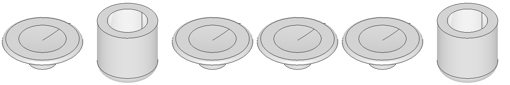

Reconstructed part sequence: 49, decoded part sequence: 1

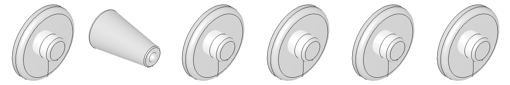

Reconstructed part sequence: 49, decoded part sequence: 2

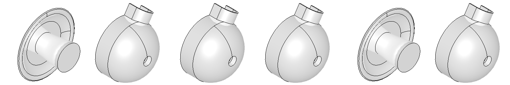

Reconstructed part sequence: 49, decoded part sequence: 3

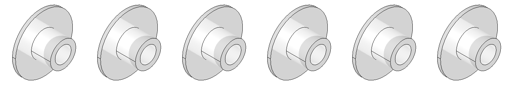

Reconstructed part sequence: 49, decoded part sequence: 4

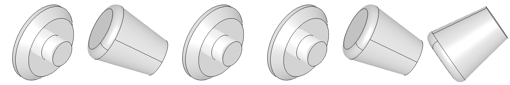

Reconstructed part sequence: 49, decoded part sequence: 5

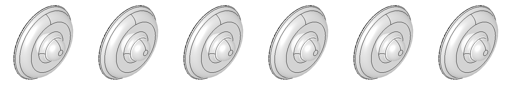

Reconstructed part sequence: 49, decoded part sequence: 6

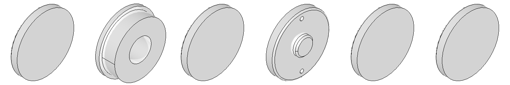

Reconstructed part sequence: 49, decoded part sequence: 7

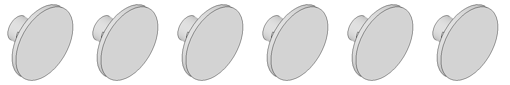

Reconstructed part sequence: 49, decoded part sequence: 8

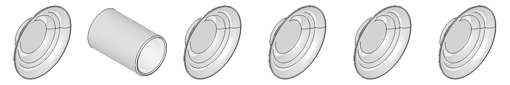

Reconstructed part sequence: 49, decoded part sequence: 9

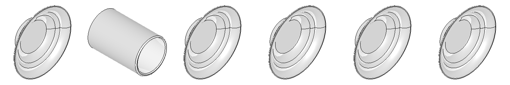

In [186]:
vid = '00'
rec_seq_idx = 49
for dec_seq_idx in range(10):
    img_md_list = []
    for img_idx in all_decoded_seq_list[rec_seq_idx][dec_seq_idx]:
        img_md = all_md[img_idx]
        img_md_list.append(img_md)

        img_name_list = extend_metadata_to_filepath(img_md_list, vid)

    display_image_grid(f'Reconstructed part sequence: {rec_seq_idx}, decoded part sequence: {dec_seq_idx}', img_name_list)

Original part sequence: 0

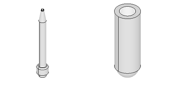

In [30]:
vid = '00'
rec_seq_idx = 0

img_md_list = []
for img_idx in all_ori_closest_emb_list[rec_seq_idx]:
    img_md = all_md[img_idx]
    img_md_list.append(img_md)

img_name_list = extend_metadata_to_filepath(img_md_list, vid)

display_image_grid(f'Original part sequence: {rec_seq_idx}', img_name_list)

In [ ]:
# vid = '00'
# rec_seq_idx = 79

img_md_list = []
for img_idx in all_rec_closest_emb_list[rec_seq_idx]:
    img_md = all_md[img_idx]
    img_md_list.append(img_md)

img_name_list = extend_metadata_to_filepath(img_md_list, vid)

display_image_grid(f'Decoded part sequence: {rec_seq_idx}', img_name_list)

In [31]:
print(a[:10])

[('124156_f866e8fb', ([12786], 0.19549445807933807)), ('31831_12689eab', ([80592, 80602, 80540], 0.22357367972532907)), ('23162_7e2f3d77', ([57535, 57533, 57526], 0.22405020892620087)), ('33176_fe782a57', ([82504, 82478, 82520], 0.22723499437173209)), ('20176_a02bde39', ([46163, 46181, 46167], 0.2288798193136851)), ('24716_66b69afc', ([66227], 0.22908712923526764)), ('72047_1cb2e47e', ([123351, 123429, 123414], 0.2312022844950358)), ('38396_3b96876b', ([91286, 91261, 91283], 0.23136070867379507)), ('56048_37ddee5d', ([115210, 115260, 115203], 0.23154300451278687)), ('141168_03e1161c', ([35207, 35206], 0.23233125358819962))]


In [48]:
len(all_md)

141245

In [52]:
target = all_ori_closest_emb_list[0]

In [54]:
for res in a:
    if res[1][0] == target:
        print(res[1][1])

0.41104353964328766


decoded part sequence: 0, average distance: 0.19549445807933807, assembly id: 124156_f866e8fb

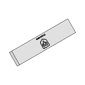

decoded part sequence: 1, average distance: 0.22357367972532907, assembly id: 31831_12689eab

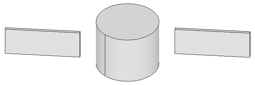

decoded part sequence: 2, average distance: 0.22405020892620087, assembly id: 23162_7e2f3d77

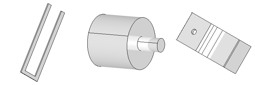

decoded part sequence: 3, average distance: 0.22723499437173209, assembly id: 33176_fe782a57

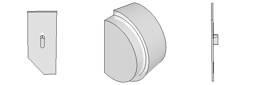

decoded part sequence: 4, average distance: 0.2288798193136851, assembly id: 20176_a02bde39

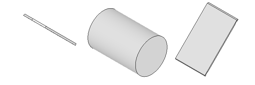

decoded part sequence: 5, average distance: 0.22908712923526764, assembly id: 24716_66b69afc

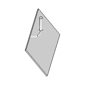

decoded part sequence: 6, average distance: 0.2312022844950358, assembly id: 72047_1cb2e47e

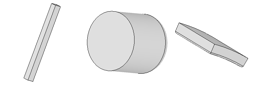

decoded part sequence: 7, average distance: 0.23136070867379507, assembly id: 38396_3b96876b

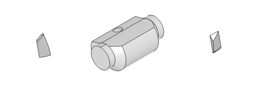

decoded part sequence: 8, average distance: 0.23154300451278687, assembly id: 56048_37ddee5d

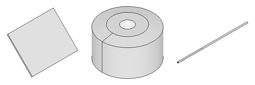

decoded part sequence: 9, average distance: 0.23233125358819962, assembly id: 141168_03e1161c

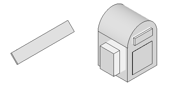

decoded part sequence: 10, average distance: 0.2334719846645991, assembly id: 89325_8435fdb8

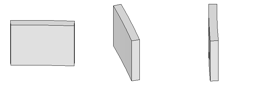

decoded part sequence: 11, average distance: 0.2335880994796753, assembly id: 104805_af0cfc04

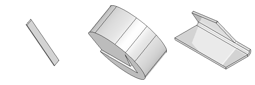

decoded part sequence: 12, average distance: 0.23359134793281555, assembly id: 43172_bebbafc3

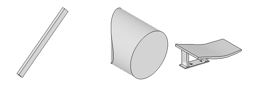

decoded part sequence: 13, average distance: 0.23418140908082327, assembly id: 131711_b6dd09f7

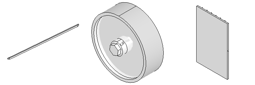

decoded part sequence: 14, average distance: 0.2345259686311086, assembly id: 135525_374a3c36

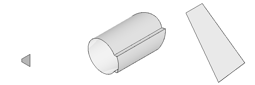

decoded part sequence: 15, average distance: 0.2349762370189031, assembly id: 45611_8305089e

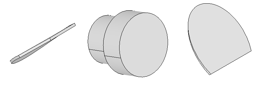

decoded part sequence: 16, average distance: 0.2357954978942871, assembly id: 43782_69b05579

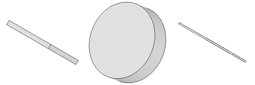

decoded part sequence: 17, average distance: 0.23626873890558878, assembly id: 23120_f7c9092f

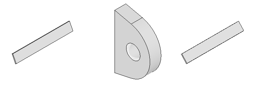

decoded part sequence: 18, average distance: 0.2363324761390686, assembly id: 48400_cd769ba9

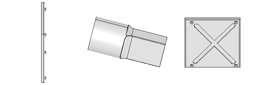

decoded part sequence: 19, average distance: 0.23642314473787943, assembly id: 54767_970a0e5a

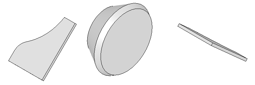

In [47]:
vid = '00'
rec_seq_idx = 49
for dec_seq_idx, (aid, (indices, avg_dist)) in enumerate(a[:20]):
    img_md_list = []
    for index in indices:
        img_md = all_md[index]
        img_md_list.append(img_md)

        img_name_list = extend_metadata_to_filepath(img_md_list, vid)

    display_image_grid(f'decoded part sequence: {dec_seq_idx}, average distance: {avg_dist}, assembly id: {aid}', img_name_list)